Name: Anuj Prasad Pradhan

ID:2408570

In [1]:
import zipfile
import os

# Path to your zip file
zip_path = "/content/drive/MyDrive/ArtificialIntelligenceandMachineLearning/week5/FruitinAmazon.zip"
extract_path = "dataset"

# Extract all files
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Dataset extracted to: dataset


In [2]:
import os

print(os.listdir("dataset"))


['FruitinAmazon']


#Task 1: Explore and Clean Dataset
Visualize random samples from each fruit class.

Check for corrupted images.

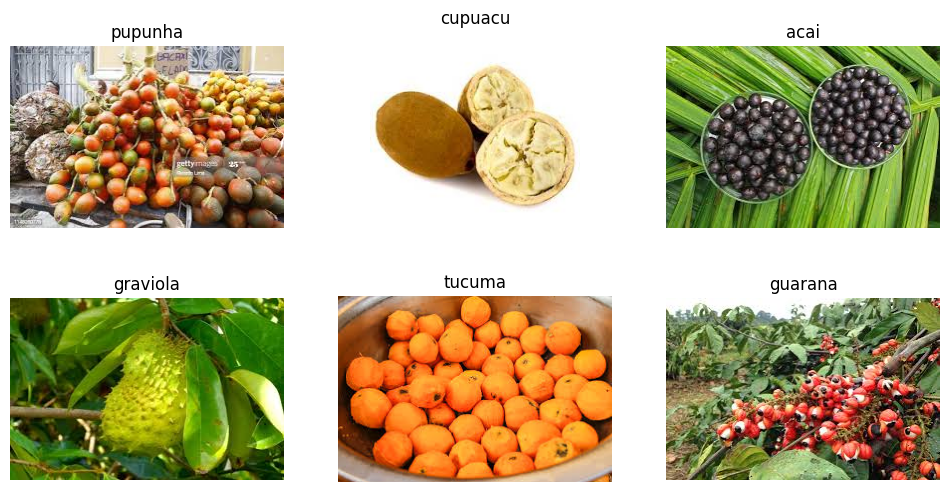

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

train_dir = os.path.join(extract_path, "FruitinAmazon", "train")
class_names = os.listdir(train_dir)

plt.figure(figsize=(12, 6))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    img_files = os.listdir(cls_path)
    random_img = random.choice(img_files)
    img = Image.open(os.path.join(cls_path, random_img))
    plt.subplot(2, (len(class_names)+1)//2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.show()

In [5]:
corrupted = []
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_path):
        try:
            img = Image.open(os.path.join(cls_path, img_file))
            img.verify()
        except:
            corrupted.append(img_file)

print("Corrupted files:", corrupted)


Corrupted files: []


#Task 2: Preprocess with Keras
Load and normalize images using

image_dataset_from_directory.

In [6]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=123
).map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=0.2,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3: Build a CNN Model
Objective: Define a Convolutional Neural Network for fruit classification.

In [7]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Train the Model
Objective: Fit the CNN using training and validation sets.

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 786ms/step - accuracy: 0.1389 - loss: 2.1129 - val_accuracy: 0.0556 - val_loss: 2.0659
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 666ms/step - accuracy: 0.2083 - loss: 1.7496 - val_accuracy: 0.0000e+00 - val_loss: 1.7626
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 650ms/step - accuracy: 0.3056 - loss: 1.5962 - val_accuracy: 0.5556 - val_loss: 1.5239
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4167 - loss: 1.3904 - val_accuracy: 0.4444 - val_loss: 1.4067
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 799ms/step - accuracy: 0.4583 - loss: 1.2918 - val_accuracy: 0.5556 - val_loss: 1.0318
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 648ms/step - accuracy: 0.4861 - loss: 1.2498 - val_accuracy: 0.7222 - val_loss: 1.2084
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 653ms/step - accuracy: 0.5139 - loss: 1.1929 - val_accuracy: 0.6667 - val_loss: 1.3763
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 729ms/step - accuracy: 0.6111 - loss: 1.0394 - val_accuracy: 0.6111 - val_loss

#Task 5: Evaluate the Model
Objective: Test performance on unseen data.

In [10]:
test_dir = os.path.join(extract_path, "FruitinAmazon", "test")

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
).map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6667 - loss: 0.7971
Test Accuracy: 0.6666666865348816


#Task 6: Visualize Training Results
Objective: Plot accuracy and loss curves.

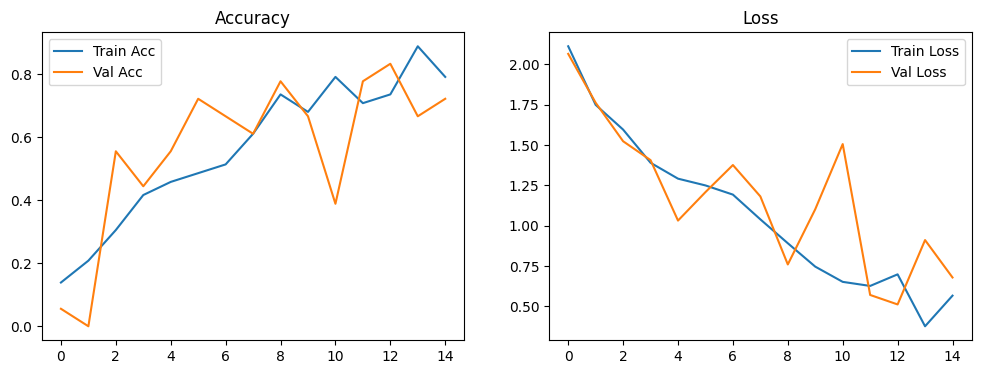

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


#Task 7: Predict on New Images
Objective: Test the model with a single image.

In [13]:
import numpy as np
import os
import random
import tensorflow as tf # Ensure tf is imported for load_img and img_to_array

# test_dir and class_names are available from previous cells

# Select a random class for prediction from the known class_names
random_class = random.choice(class_names)
class_test_path = os.path.join(test_dir, random_class)

# List images in the selected class directory and pick one randomly
img_files = os.listdir(class_test_path)
if not img_files:
    raise ValueError(f"No images found in {class_test_path}")

img_filename = random.choice(img_files)
img_path = os.path.join(class_test_path, img_filename)

print(f"Attempting to predict on: {img_path}")

img = tf.keras.utils.load_img(img_path, target_size=(128,128))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

predictions = model.predict(img_array)
pred_class = class_names[np.argmax(predictions)]
print("Predicted class:", pred_class)

Attempting to predict on: dataset/FruitinAmazon/test/guarana/download (4).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted class: graviola
